In [22]:
import sys, os, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm

# ── Project root ─────────────────────────────────────────────────────────────
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'toy_domain'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'MedGrid'))

import med_grid_env  # registers MedGrid-v0 and MedGrid-discrete-v0

# ── Discrete run to analyse ───────────────────────────────────────────────────
DISC_RUN_NAME = 'medgrid_discrete_15bins_100kframes'   # change to match -info flag used during training
DISC_RUN_DIR  = os.path.join(PROJECT_ROOT, 'runs', DISC_RUN_NAME)
N_BINS_DISC   = 15   # must match -n_bins used during training

# ── Hyper-parameters ─────────────────────────────────────────────────────────
N_TAU       = 32
ETA         = 0.25
DEVICE      = 'cuda:0' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
FIXED_STATE = [10.0, 0.0]   # start corner
SIZE        = 10.0

N_KEEP = max(1, int(ETA * N_TAU))
print(f'CVaR: keeping {N_KEEP}/{N_TAU} quantiles (eta={ETA})')
print(f'Fixed state: {FIXED_STATE},  n_bins: {N_BINS_DISC}  ({N_BINS_DISC**2} actions)')
print(f'Device: {DEVICE}')

CVaR: keeping 8/32 quantiles (eta=0.25)
Fixed state: [10.0, 0.0],  n_bins: 15  (225 actions)
Device: mps


## 1. Ground truth regions

MedGrid is a **10×10** continuous gridworld with:
* **Red (Death):** quarter-circles of radius 3 at $(0,0)$ and $(10,10)$.
* **Yellow (Trap):** annular bands $3 < d \le 5$ around each corner.
* **Blue (Recovery):** rotated ellipse at $(5,5)$, semi-axes $a=3$, $b=1.5$, tilted $-45°$.
* **Start:** $(10, 0)$.

Rasterising region map...


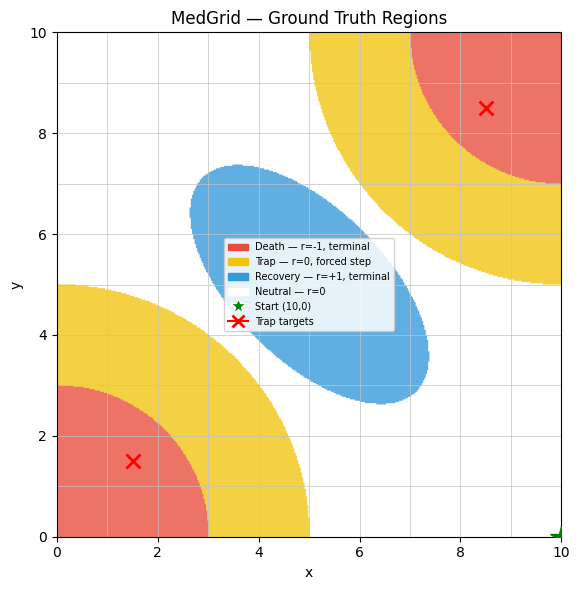

In [23]:
DEATH_R   = 3.0
TRAP_R    = 5.0
ELLIPSE_A = 3.0
ELLIPSE_B = 1.5


def classify_point(x, y):
    d_bl = np.sqrt(x**2 + y**2)
    d_tr = np.sqrt((x - 10)**2 + (y - 10)**2)
    if d_bl <= DEATH_R or d_tr <= DEATH_R:
        return 'death'
    if d_bl <= TRAP_R or d_tr <= TRAP_R:
        return 'trap'
    dx, dy = x - 5.0, y - 5.0
    if ((dx - dy)**2 / (2 * ELLIPSE_A**2) + (dx + dy)**2 / (2 * ELLIPSE_B**2)) <= 1.0:
        return 'recovery'
    return 'neutral'


def build_region_image(resolution=400):
    COLORS = {
        'death':    np.array([231,  76,  60, 200], dtype=np.uint8),
        'trap':     np.array([241, 196,  15, 200], dtype=np.uint8),
        'recovery': np.array([ 52, 152, 219, 200], dtype=np.uint8),
        'neutral':  np.array([255, 255, 255, 255], dtype=np.uint8),
    }
    xs = np.linspace(0, SIZE, resolution)
    ys = np.linspace(0, SIZE, resolution)
    img = np.zeros((resolution, resolution, 4), dtype=np.uint8)
    for j, y in enumerate(ys):
        for i, x in enumerate(xs):
            img[j, i] = COLORS[classify_point(x, y)]
    return img


def plot_ground_truth(ax=None, resolution=400):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure
    ax.imshow(build_region_image(resolution), origin='lower',
              extent=[0, SIZE, 0, SIZE], aspect='equal')
    for i in range(11):
        ax.axhline(i, color='#bdc3c7', lw=0.5, zorder=2)
        ax.axvline(i, color='#bdc3c7', lw=0.5, zorder=2)
    ax.plot(1.5, 1.5, 'rx', markersize=10, markeredgewidth=2, zorder=4)
    ax.plot(8.5, 8.5, 'rx', markersize=10, markeredgewidth=2, zorder=4)
    ax.plot(10, 0, 'g*', markersize=16, zorder=5)
    legend_patches = [
        mpatches.Patch(color='#e74c3c', label='Death — r=-1, terminal'),
        mpatches.Patch(color='#f1c40f', label='Trap — r=0, forced step'),
        mpatches.Patch(color='#3498db', label='Recovery — r=+1, terminal'),
        mpatches.Patch(color='white',   label='Neutral — r=0'),
        plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='g', markersize=12, label='Start (10,0)'),
        plt.Line2D([0],[0], marker='x', color='r', markersize=8, markeredgewidth=2, label='Trap targets'),
    ]
    ax.legend(handles=legend_patches, loc='center', fontsize=7,
              framealpha=0.85, bbox_to_anchor=(0.5, 0.5))
    ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('MedGrid — Ground Truth Regions')
    return fig, ax


print('Rasterising region map...')
fig, ax = plot_ground_truth()
plt.tight_layout()
plt.show()

## 2. Load discrete agents

Train first if needed:
```bash
cd toy_domain
../.venv/bin/python run.py -env MedGrid -action_mode discrete -n_bins 11 \
    -agent iqn -ded -frames 500000 -info medgrid_iqn_discrete
```

In [24]:
disc_agent, disc_qd, disc_qr = None, None, None
try:
    with open(os.path.join(DISC_RUN_DIR, f'{DISC_RUN_NAME}_agent.pkl'), 'rb') as f:
        disc_agent = pickle.load(f)
    print('Loaded discrete main agent')
    with open(os.path.join(DISC_RUN_DIR, f'{DISC_RUN_NAME}_Qd.pkl'), 'rb') as f:
        disc_qd = pickle.load(f)
    with open(os.path.join(DISC_RUN_DIR, f'{DISC_RUN_NAME}_Qr.pkl'), 'rb') as f:
        disc_qr = pickle.load(f)
    print('Loaded discrete Qd and Qr networks')
except FileNotFoundError as e:
    print(f'Agents not found ({e}) — train first with the command above.')

Loaded discrete main agent
Agents not found ([Errno 2] No such file or directory: '/Users/erinsarlak/Desktop/ContinuousDeD/runs/medgrid_discrete_15bins_100kframes/medgrid_discrete_15bins_100kframes_Qd.pkl') — train first with the command above.


## 3. Discrete agent — CVaR Q-value heatmaps over action grid at state (10, 0)

The discrete IQN outputs quantiles for **all actions simultaneously**: `forward(state, n_tau) -> (1, n_tau, n_actions)`.  
We compute the lower CVaR at level η for each action, then reshape the `n_bins²` values back into the `(n_bins, n_bins)` spatial grid to visualise them in the 10×10 coordinate frame.

In [25]:
def compute_discrete_action_heatmap(disc_ded_agent, state=FIXED_STATE,
                                     n_bins=N_BINS_DISC, n_tau=N_TAU, eta=ETA, device=DEVICE):
    """
    Compute CVaR Q-values for all n_bins^2 discrete actions at a fixed state.

    The discrete IQN forward pass returns (1, n_tau, n_actions), giving all
    action quantiles in one shot.

    Returns
    -------
    heatmap : (n_bins, n_bins) float32 — row=x bin, col=y bin
    bins    : 1-D array of grid coordinates (same for both axes)
    """
    n_keep = max(1, int(eta * n_tau))
    network = disc_ded_agent.qnetwork_local.to(device)
    network.eval()

    s = torch.tensor([state], dtype=torch.float32).to(device)  # (1, 2)

    with torch.no_grad():
        quantiles, _ = network.forward(s, num_tau=n_tau)
        # quantiles: (1, n_tau, n_actions)

    q = quantiles.squeeze(0).cpu().numpy()     # (n_tau, n_actions)
    q_sorted = np.sort(q, axis=0)              # ascending along quantile axis
    cvar = q_sorted[:n_keep, :].mean(axis=0)   # (n_actions,)

    # action i encodes (bins[i//n_bins], bins[i%n_bins])
    heatmap = cvar.reshape(n_bins, n_bins)
    bins = np.linspace(0.0, SIZE, n_bins, dtype=np.float32)
    return heatmap, bins


def plot_discrete_action_heatmap(heatmap, bins, title, ax=None):
    """
    Plot the discrete CVaR heatmap in the 10x10 MedGrid coordinate frame.
    x-axis = action x target, y-axis = action y target.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    # heatmap[i,j] = CVaR for action (bins[i], bins[j])
    # transpose: rows->y, cols->x for imshow origin='lower'
    display = heatmap.T

    norm = TwoSlopeNorm(vmin=display.min(), vcenter=0, vmax=max(display.max(), 1e-6))
    im = ax.imshow(
        display,
        origin='lower',
        extent=[bins[0], bins[-1], bins[0], bins[-1]],
        cmap='RdBu',
        norm=norm,
        aspect='equal',
        interpolation='nearest',
    )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='CVaR Q')

    for b in bins:
        ax.axvline(b, color='k', lw=0.4, alpha=0.4)
        ax.axhline(b, color='k', lw=0.4, alpha=0.4)

    ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
    ax.set_xlabel('action x'); ax.set_ylabel('action y')
    ax.set_title(title)
    return fig, ax

### 3a. Q_d (danger network) — discrete action grid at state (10, 0)
Actions leading toward danger should be **red (≈ −1)**; safe actions **white/blue**.

In [27]:
assert disc_qd is not None, 'disc_qd not loaded — train first with the command above'

print(f'Computing discrete Qd heatmap at state {FIXED_STATE}...')
disc_heatmap_d, disc_bins = compute_discrete_action_heatmap(disc_qd)
print(f'  range: [{disc_heatmap_d.min():.3f}, {disc_heatmap_d.max():.3f}]')

fig, ax = plot_discrete_action_heatmap(disc_heatmap_d, disc_bins,
                                        title=f'$Q_d$ CVaR (η={ETA}) @ {FIXED_STATE}  [discrete]')
plt.tight_layout()
plt.show()

AssertionError: disc_qd not loaded — train first with the command above

### 3b. Q_r (recovery network) — discrete action grid at state (10, 0)
Actions leading toward recovery should be **blue (≈ +1)**; others **white/red**.

Computing discrete Qr heatmap at state [10.0, 0.0]...
  range: [-0.001, 0.998]


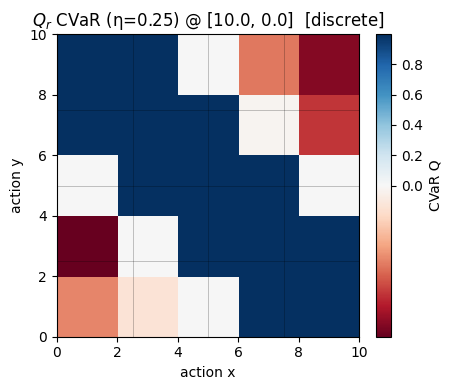

In [ ]:
assert disc_qr is not None, 'disc_qr not loaded — train first with the command above'

print(f'Computing discrete Qr heatmap at state {FIXED_STATE}...')
disc_heatmap_r, _ = compute_discrete_action_heatmap(disc_qr)
print(f'  range: [{disc_heatmap_r.min():.3f}, {disc_heatmap_r.max():.3f}]')

fig, ax = plot_discrete_action_heatmap(disc_heatmap_r, disc_bins,
                                        title=f'$Q_r$ CVaR (η={ETA}) @ {FIXED_STATE}  [discrete]')
plt.tight_layout()
plt.show()

## 4. Side-by-side summary — discrete agent

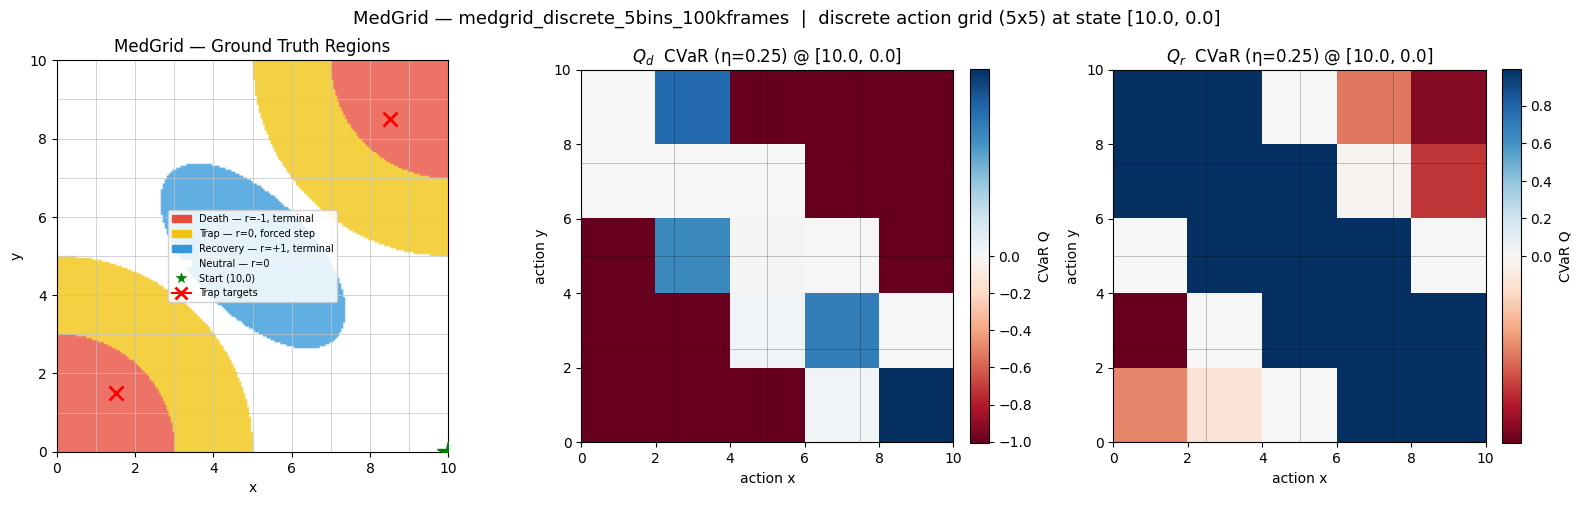

Saved to /Users/erinsarlak/Desktop/ContinuousDeD/runs/medgrid_discrete_5bins_100kframes/medgrid_disc_ded_action_heatmaps.png


In [ ]:
if disc_qd is not None and disc_qr is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    plot_ground_truth(ax=axes[0], resolution=200)
    plot_discrete_action_heatmap(disc_heatmap_d, disc_bins,
                                  title=f'$Q_d$  CVaR (η={ETA}) @ {FIXED_STATE}', ax=axes[1])
    plot_discrete_action_heatmap(disc_heatmap_r, disc_bins,
                                  title=f'$Q_r$  CVaR (η={ETA}) @ {FIXED_STATE}', ax=axes[2])

    fig.suptitle(
        f'MedGrid — {DISC_RUN_NAME}  |  discrete action grid ({N_BINS_DISC}x{N_BINS_DISC}) at state {FIXED_STATE}',
        fontsize=13)
    plt.tight_layout()
    out_path = os.path.join(DISC_RUN_DIR, 'medgrid_disc_ded_action_heatmaps.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to', out_path)
else:
    print('Skipped — no trained agents loaded.')

## 5. Sweep across states of interest

Evaluate the discrete CVaR heatmaps at multiple states to see how the Q-value landscape shifts depending on where the agent currently is.

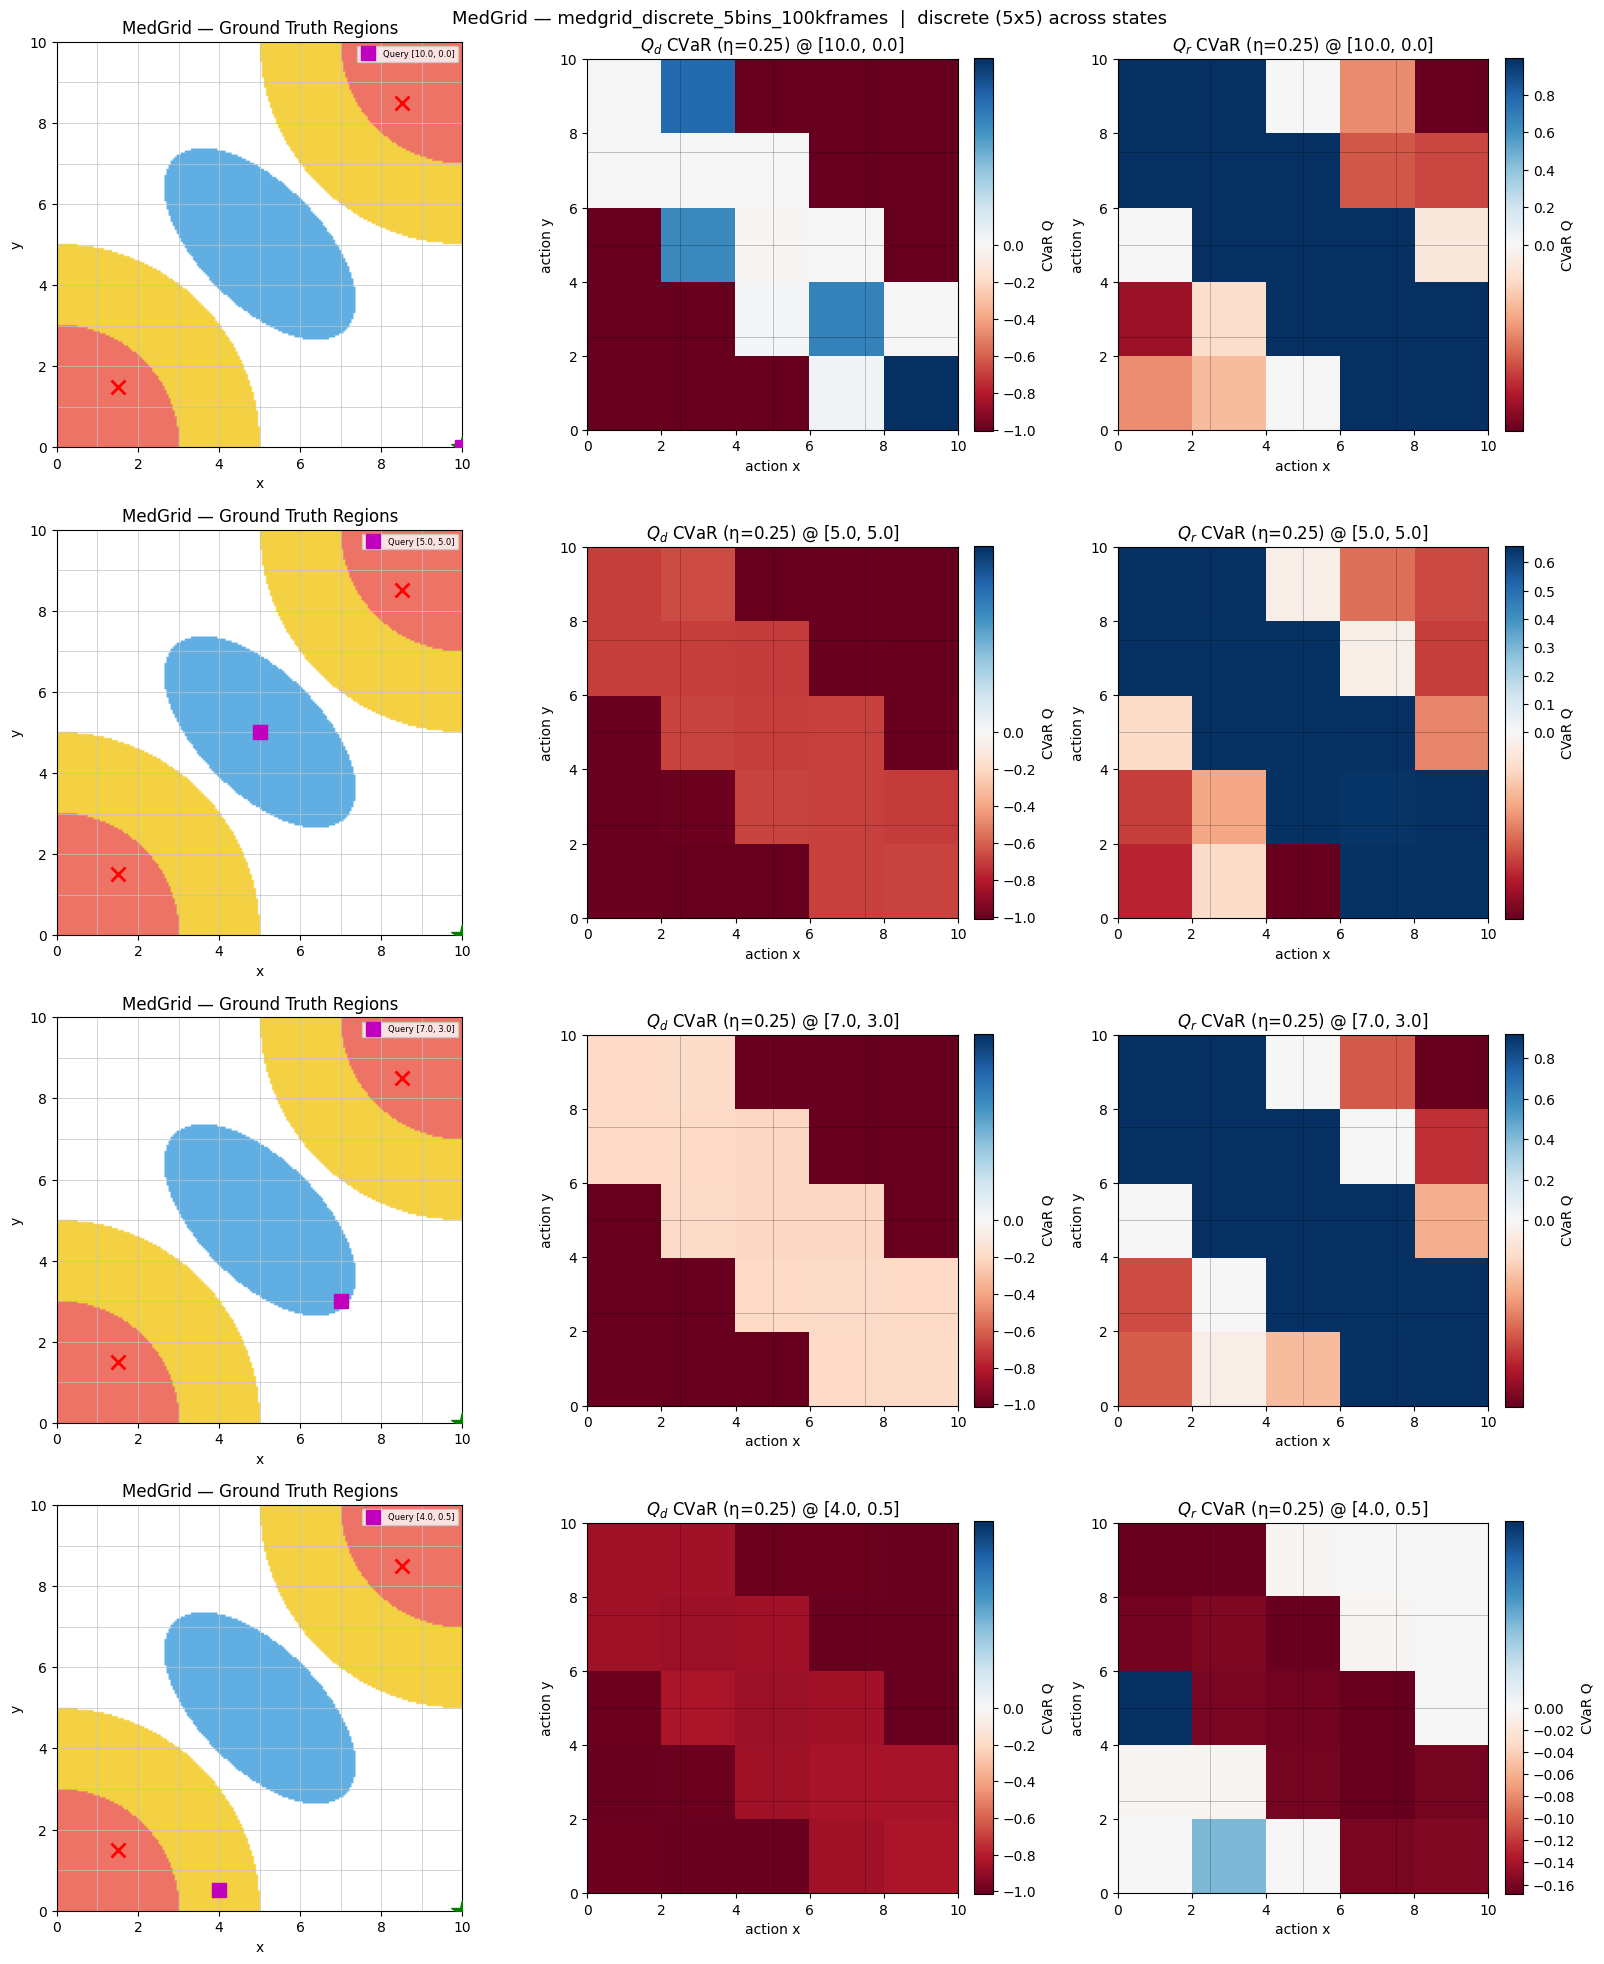

Saved to /Users/erinsarlak/Desktop/ContinuousDeD/runs/medgrid_discrete_5bins_100kframes/medgrid_disc_ded_multi_state_heatmaps.png


In [ ]:
EVAL_STATES = [
    [10.0,  0.0],   # start corner
    [ 5.0,  5.0],   # centre (recovery zone)
    [ 7.0,  3.0],   # neutral, mid-right
    [ 4.0,  0.5],   # inside BL trap band
]

if disc_qd is not None and disc_qr is not None:
    fig, axes = plt.subplots(len(EVAL_STATES), 3,
                             figsize=(16, 5 * len(EVAL_STATES)))

    for row, state in enumerate(EVAL_STATES):
        hm_d, bins = compute_discrete_action_heatmap(disc_qd, state=state)
        hm_r, _    = compute_discrete_action_heatmap(disc_qr, state=state)

        plot_ground_truth(ax=axes[row, 0], resolution=200)
        axes[row, 0].plot(state[0], state[1], 'ms', markersize=10, zorder=6,
                          label=f'Query {state}')
        axes[row, 0].legend(loc='upper right', fontsize=6)

        plot_discrete_action_heatmap(hm_d, bins,
                                      title=f'$Q_d$ CVaR (η={ETA}) @ {state}',
                                      ax=axes[row, 1])
        plot_discrete_action_heatmap(hm_r, bins,
                                      title=f'$Q_r$ CVaR (η={ETA}) @ {state}',
                                      ax=axes[row, 2])

    fig.suptitle(
        f'MedGrid — {DISC_RUN_NAME}  |  discrete ({N_BINS_DISC}x{N_BINS_DISC}) across states',
        fontsize=13)
    plt.tight_layout()
    out_path = os.path.join(DISC_RUN_DIR, 'medgrid_disc_ded_multi_state_heatmaps.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to', out_path)
else:
    print('Skipped — no trained agents loaded.')

## 6. Region Detection Metrics — Precision, Recall, F1, Confusion Matrix, Boundary IoU

The discrete agent predicts Q-values for all `n_bins²` actions at once. We treat each action bin center as a candidate **target position** (queried from the start state) and compare the agent's prediction against the ground-truth region label.

**Prediction rule (winner-takes-all):**
- If `CVaR(Q_d) < 0` and `|CVaR(Q_d)| ≥ CVaR(Q_r)` → **danger**
- Else if `CVaR(Q_r) > 0` → **recovery**
- Else → **safe**

GT is collapsed to 3 classes: `danger = {death, trap}`, `recovery`, `safe = {neutral}`.

For more robust metrics and Boundary IoU, the agent predictions are upsampled to a **200×200 dense grid** via nearest-neighbour.

In [ ]:
from sklearn.metrics import (precision_recall_fscore_support,
                               confusion_matrix, ConfusionMatrixDisplay)
from scipy.ndimage import binary_erosion, binary_dilation

assert disc_qd is not None and disc_qr is not None, "Need loaded agents — run cell 2 first"

DENSE_RES = 200   # pixels per axis for upsampled evaluation
CLASSES   = ['dead_end', 'not_dead_end']

# ── 1. CVaR predictions from the start state ─────────────────────────────────
hm_d_eval, bins_eval = compute_discrete_action_heatmap(disc_qd, state=FIXED_STATE)
hm_r_eval, _         = compute_discrete_action_heatmap(disc_qr, state=FIXED_STATE)
n_bins = len(bins_eval)

# ── 2. Classify each bin: Q_d < 0 → dead_end, else → not_dead_end ─────────────
pred_grid = np.full((n_bins, n_bins), 'not_dead_end', dtype=object)
for i in range(n_bins):
    for j in range(n_bins):
        if hm_d_eval[i, j] < 0:
            pred_grid[i, j] = 'dead_end'

# ── 3. Build dense 200×200 maps (nearest-neighbour upsampling) ────────────────
xs_dense = np.linspace(0, SIZE, DENSE_RES)
ys_dense = np.linspace(0, SIZE, DENSE_RES)

gt_dense   = np.empty((DENSE_RES, DENSE_RES), dtype=object)
pred_dense = np.empty((DENSE_RES, DENSE_RES), dtype=object)

for j, y in enumerate(ys_dense):
    for i, x in enumerate(xs_dense):
        raw = classify_point(x, y)
        gt_dense[j, i] = 'dead_end' if raw in ('death', 'trap') else 'not_dead_end'

        bi = int(np.argmin(np.abs(bins_eval - x)))
        bj = int(np.argmin(np.abs(bins_eval - y)))
        pred_dense[j, i] = pred_grid[bi, bj]

gt_flat   = gt_dense.ravel()
pred_flat = pred_dense.ravel()

print(f"Dense grid: {DENSE_RES}×{DENSE_RES} = {DENSE_RES**2} pixels\n")
print(f"{'Class':<14} {'GT count':>10} {'Pred count':>12}")
print("─" * 38)
for c in CLASSES:
    print(f"{c:<14} {(gt_flat == c).sum():>10} {(pred_flat == c).sum():>12}")


In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(gt_flat, pred_flat, labels=CLASSES)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
ax.set_title(
    f'Confusion Matrix — {DISC_RUN_NAME}\n'
    f'(dense 200×200 grid, upsampled from {n_bins}×{n_bins} bins, source state {FIXED_STATE})',
    fontsize=10)
plt.tight_layout()
out_path = os.path.join(DISC_RUN_DIR, 'medgrid_disc_confusion_matrix.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved to', out_path)


In [ ]:
# ── Precision / Recall / F1 ───────────────────────────────────────────────────
prec, rec, f1, support = precision_recall_fscore_support(
    gt_flat, pred_flat, labels=CLASSES, zero_division=0
)

print(f"{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("─" * 56)
for i, c in enumerate(CLASSES):
    print(f"{c:<12} {prec[i]:>10.3f} {rec[i]:>10.3f} {f1[i]:>10.3f} {support[i]:>10,}")
print("─" * 56)
macro_p  = prec.mean()
macro_r  = rec.mean()
macro_f1 = f1.mean()
print(f"{'Macro avg':<12} {macro_p:>10.3f} {macro_r:>10.3f} {macro_f1:>10.3f}")

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
metrics = [prec, rec, f1]
titles  = ['Precision', 'Recall', 'F1 Score']
colors  = ['#e74c3c', '#3498db', '#2ecc71']

for ax, vals, title, col in zip(axes, metrics, titles, colors):
    bars = ax.bar(CLASSES, vals, color=col, alpha=0.8, edgecolor='black', linewidth=0.7)
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score' if ax is axes[0] else '')
    ax.axhline(macro_p if title == 'Precision' else
               macro_r if title == 'Recall' else macro_f1,
               color='k', linestyle='--', linewidth=1, label='Macro avg')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

fig.suptitle(f'Per-class Metrics — {DISC_RUN_NAME}  ({n_bins}×{n_bins} bins)', fontsize=12)
plt.tight_layout()
out_path = os.path.join(DISC_RUN_DIR, 'medgrid_disc_prec_rec_f1.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved to', out_path)


In [ ]:
# ── Boundary IoU ─────────────────────────────────────────────────────────────
# Boundary IoU (Cheng et al., 2021):
#   B_d(M) = M minus erosion(M, d)   — pixels inside mask within d of the edge
#   Boundary IoU = |B_d(GT) ∩ B_d(Pred)| / |B_d(GT) ∪ B_d(Pred)|
#
# d = 5 px ≈ 0.25 world-units at 200 px resolution

BOUNDARY_D = 5

def get_boundary(mask, d=BOUNDARY_D):
    if mask.sum() == 0:
        return np.zeros_like(mask, dtype=bool)
    eroded = binary_erosion(mask, iterations=d)
    return mask & ~eroded

def boundary_iou(gt_mask, pred_mask, d=BOUNDARY_D):
    bg = get_boundary(gt_mask, d)
    bp = get_boundary(pred_mask, d)
    inter = (bg & bp).sum()
    union = (bg | bp).sum()
    return float(inter) / (float(union) + 1e-8), bg, bp

gt_deadend_mask   = (gt_dense   == 'dead_end')
pred_deadend_mask = (pred_dense == 'dead_end')

biou_deadend, bg_d, bp_d = boundary_iou(gt_deadend_mask, pred_deadend_mask)

print(f"Boundary IoU (d={BOUNDARY_D} px = {BOUNDARY_D/DENSE_RES*SIZE:.2f} world-units):")
print(f"  Dead-end zone : {biou_deadend:.3f}")

# ── Visualise GT vs Pred maps + boundary comparison ──────────────────────────
CLASS_COLORS = {
    'dead_end':     np.array([231,  76,  60], dtype=np.uint8),   # red
    'not_dead_end': np.array([220, 220, 220], dtype=np.uint8),   # light grey
}

def labels_to_rgb(label_arr):
    rgb = np.zeros((*label_arr.shape, 3), dtype=np.uint8)
    for lbl, col in CLASS_COLORS.items():
        rgb[label_arr == lbl] = col
    return rgb

gt_rgb   = labels_to_rgb(gt_dense)
pred_rgb = labels_to_rgb(pred_dense)

agree_rgb = np.where(
    (gt_dense == pred_dense)[..., None],
    np.array([46, 204, 113], dtype=np.uint8),   # correct — green
    np.array([230, 126,  34], dtype=np.uint8),   # wrong   — orange
).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, rgb, title in zip(
        axes[:3],
        [gt_rgb, pred_rgb, agree_rgb],
        ['Ground Truth', f'Agent Prediction ({n_bins}×{n_bins} bins)', 'Agreement (green=correct)']):
    ax.imshow(rgb, origin='lower', extent=[0, SIZE, 0, SIZE], aspect='equal')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    for k in range(11):
        ax.axhline(k, color='white', lw=0.3, alpha=0.5)
        ax.axvline(k, color='white', lw=0.3, alpha=0.5)

ax = axes[3]
ax.imshow(gt_rgb, origin='lower', extent=[0, SIZE, 0, SIZE], aspect='equal', alpha=0.4)

def boundary_to_coords(bnd, xs, ys):
    rows, cols = np.where(bnd)
    return xs[cols], ys[rows]

bx_gt,   by_gt   = boundary_to_coords(bg_d, xs_dense, ys_dense)
bx_pred, by_pred = boundary_to_coords(bp_d, xs_dense, ys_dense)

ax.scatter(bx_gt,   by_gt,   s=1, c='#e74c3c', label='GT dead-end boundary',   linewidths=0)
ax.scatter(bx_pred, by_pred, s=1, c='#c0392b', marker='x', label='Pred dead-end boundary', linewidths=0.3)

ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
ax.set_title(f'Boundary IoU — Dead-end zone: {biou_deadend:.3f}', fontsize=10)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(loc='upper right', fontsize=7, markerscale=5)

fig.suptitle(f'Region Detection — {DISC_RUN_NAME}  (source state {FIXED_STATE})', fontsize=12)
plt.tight_layout()
out_path = os.path.join(DISC_RUN_DIR, 'medgrid_disc_boundary_iou.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved to', out_path)
